# **Lot 1 — Exploration et préparation des données**
### **Projet NLP · Analyse de sentiment des tweets de compagnies aériennes**

**Objectifs :**
1. **EDA** — dashboard de visualisations modernes et commentées.
2. **Nettoyage** — pipeline reproductible et justifié (`src/text_cleaning.py`).
3. **Stratégie de déséquilibre** — choisie et justifiée.
4. **Découpage** — split *train / validation / test* **stratifié et figé**, sauvegardé sur disque.

> **Protocole d'évaluation figé (Lot 0) :** métrique principale = **F1-macro** (robuste au
> déséquilibre), jeu de **test figé** (15 %, intouché jusqu'à l'évaluation finale), **validation** dédiée (15 %).


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# --- Résolution robuste des chemins + import des modules projet ---
def find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "Tweets.csv").exists():
            return base
    return Path.cwd()

ROOT = find_root()
SRC  = ROOT / "delivarables" / "src"
DATA = ROOT / "data" / "Tweets.csv"
OUT  = ROOT / "delivarables" / "data_processed"; OUT.mkdir(exist_ok=True, parents=True)
FIG  = ROOT / "delivarables" / "figures"; FIG.mkdir(exist_ok=True, parents=True)
sys.path.insert(0, str(SRC))

import viz_style as vz            # systeme de design (theme sombre, helpers)
import eda_figures as ef          # figures EDA reutilisables
from text_cleaning import clean_text

vz.apply_theme()                  # applique le theme dashboard a tout le notebook
pd.set_option("display.max_colwidth", 120)
print("Racine projet :", ROOT, "| dataset:", DATA.exists())

Racine projet : C:\Users\admin\Downloads\DEEP LEARNING | dataset: True


## **1. Chargement et préparation des variables d'analyse**

In [ ]:
df = pd.read_csv(DATA)
df["n_mots"] = df["text"].str.split().str.len()           # longueur (analyse)
df["text_clean"] = df["text"].apply(clean_text)            # texte nettoye (pipeline detaille en §3)
print("Dimensions :", df.shape)
df[["airline","airline_sentiment","text"]].head(3)

Dimensions : (14640, 17)


,airline,airline_sentiment,text
0,Virgin America,neutral,@VirginAmerica What @dhepburn said.
1,Virgin America,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
2,Virgin America,neutral,@VirginAmerica I didn't today... Must mean I need to take another trip!


In [ ]:
# Valeurs manquantes (en %)
manquantes = (df.isna().mean()*100).round(1).sort_values(ascending=False)
print(manquantes[manquantes > 0])

negativereason_gold          99.8
airline_sentiment_gold       99.7
tweet_coord                  93.0
negativereason               37.3
user_timezone                32.9
tweet_location               32.3
negativereason_confidence    28.1
dtype: float64


**Lecture :** la cible `airline_sentiment` et le `text` sont **complets** (0 % manquant).
Les colonnes très lacunaires (`tweet_coord`, `*_gold`) sont des métadonnées optionnelles.
`negativereason` n'est renseignée que pour les tweets négatifs (normal).

## **2. Analyse exploratoire (EDA)**

Visualisations en **thème dashboard** (code dans `src/eda_figures.py` + `src/viz_style.py`).
On répond aux questions business : tonalité dominante, compagnie la plus critiquée, motifs,
longueur des messages, vocabulaire, fiabilité des annotations.

### **2.1 Vue d'ensemble — distribution & sentiment par compagnie**

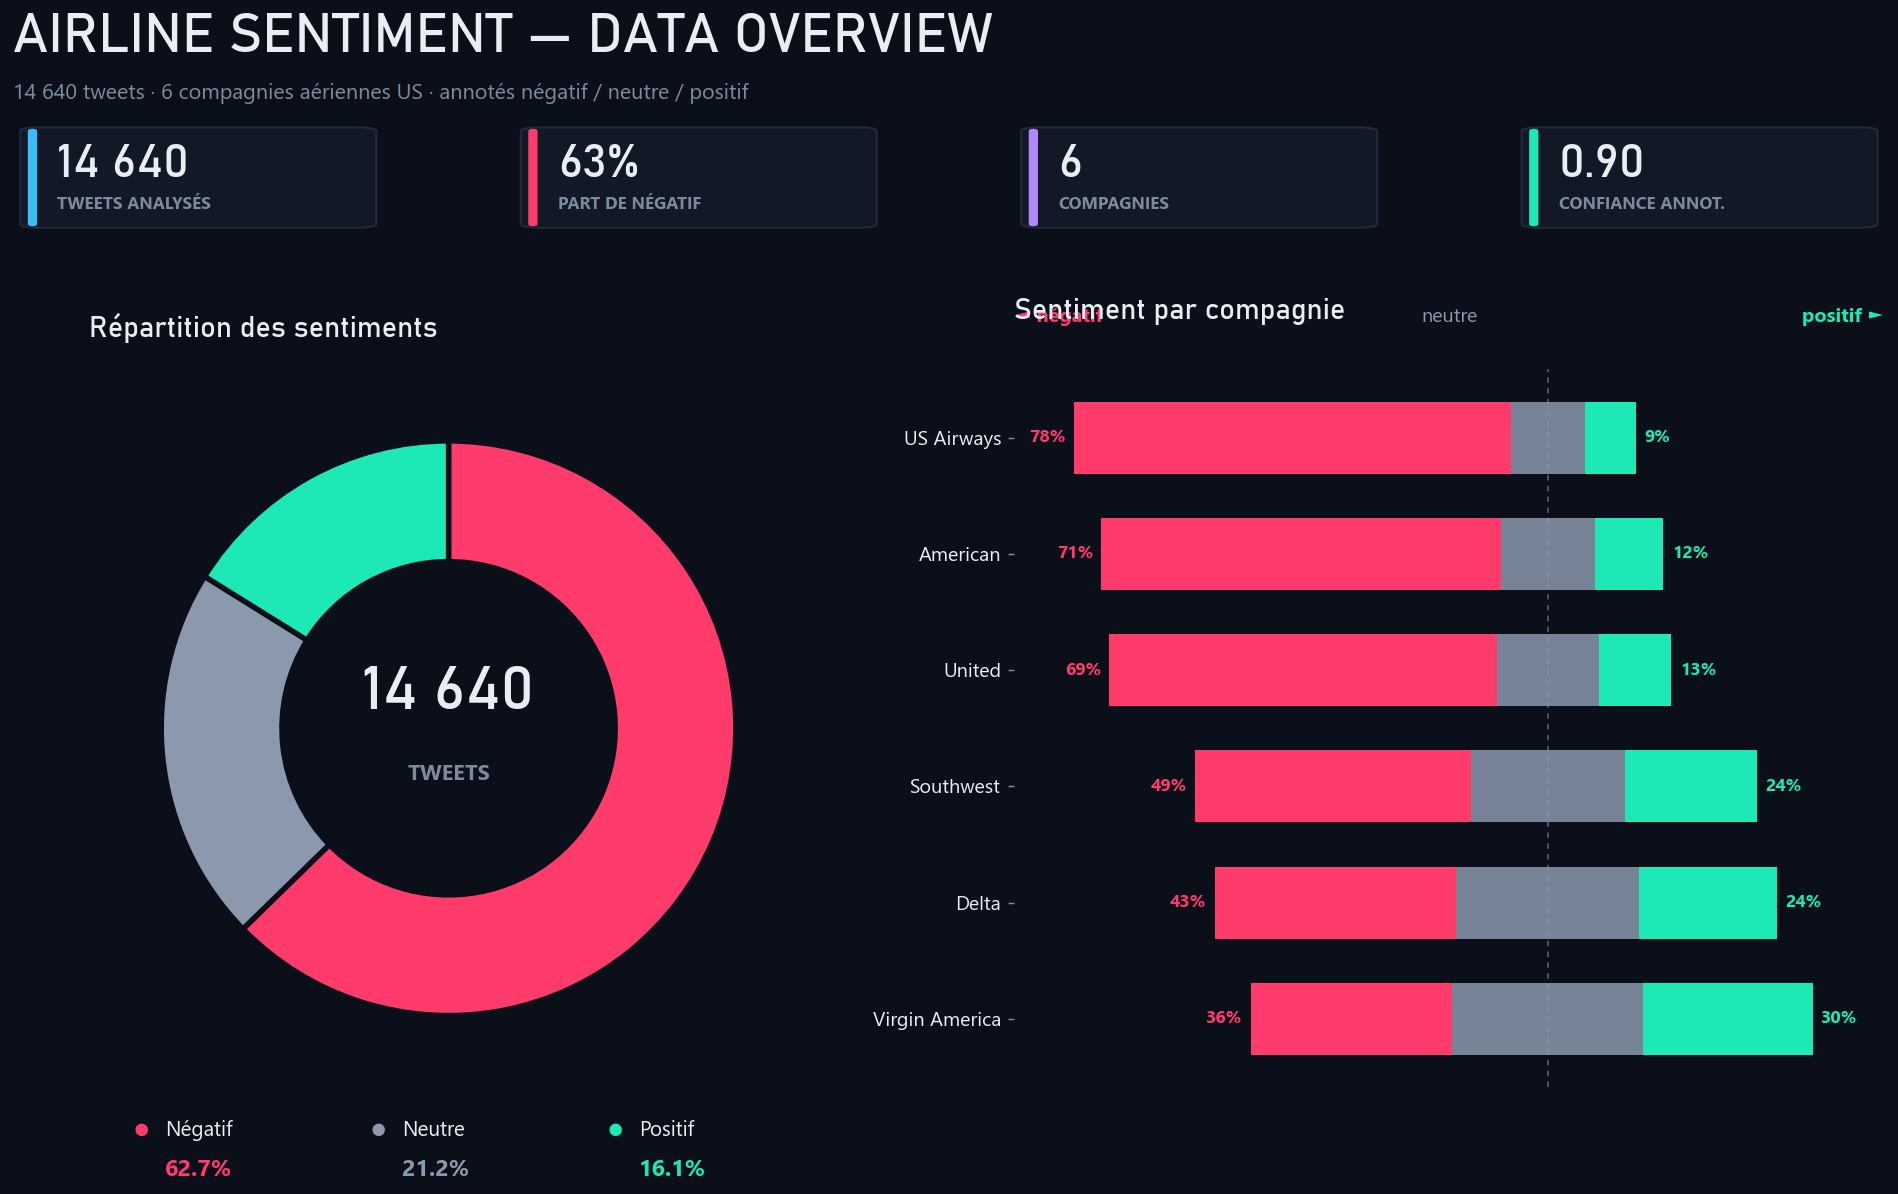

In [ ]:
fig = ef.fig_hero(df, save=FIG/"hero_dashboard.png"); plt.show()

**Commentaire :** déséquilibre marqué — **~63 % négatif**, 21 % neutre, 16 % positif →
l'accuracy serait trompeuse, on retient le **F1-macro**. Côté compagnies, **US Airways, American
et United** sont les plus critiquées (>65 % de négatif) ; **Virgin America** est la plus équilibrée.

### **2.2 Motifs d'insatisfaction**

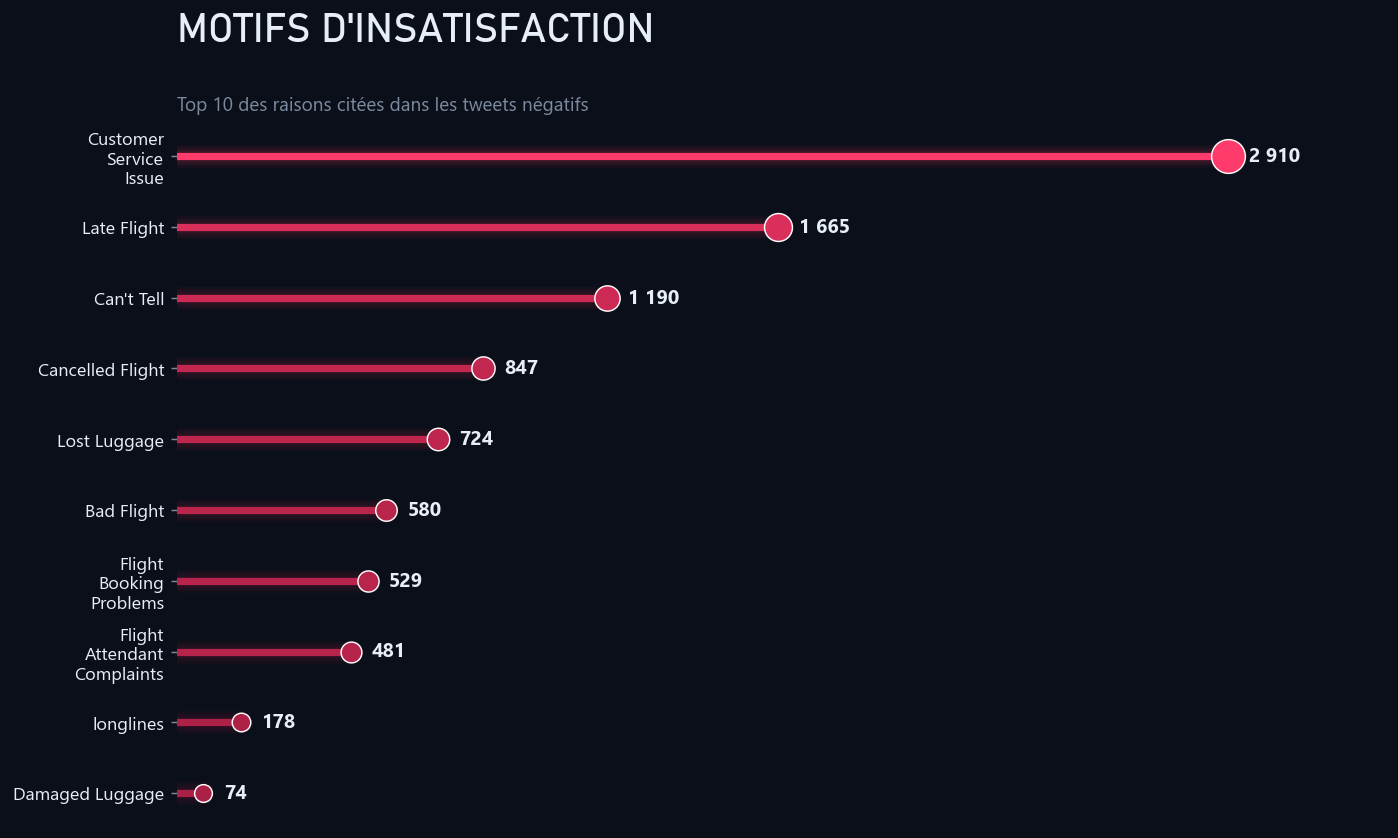

In [ ]:
fig = ef.fig_motifs(df, save=FIG/"motifs_negatifs_modern.png"); plt.show()

**Commentaire :** causes dominantes = **service client**, **vols en retard**, **annulations**,
**bagages perdus**. (« Can't Tell » = négatif dont l'annotateur n'a pas pu déterminer la cause.)
Ce sont les leviers prioritaires pour le service client.

### **2.3 Longueur des tweets par sentiment**

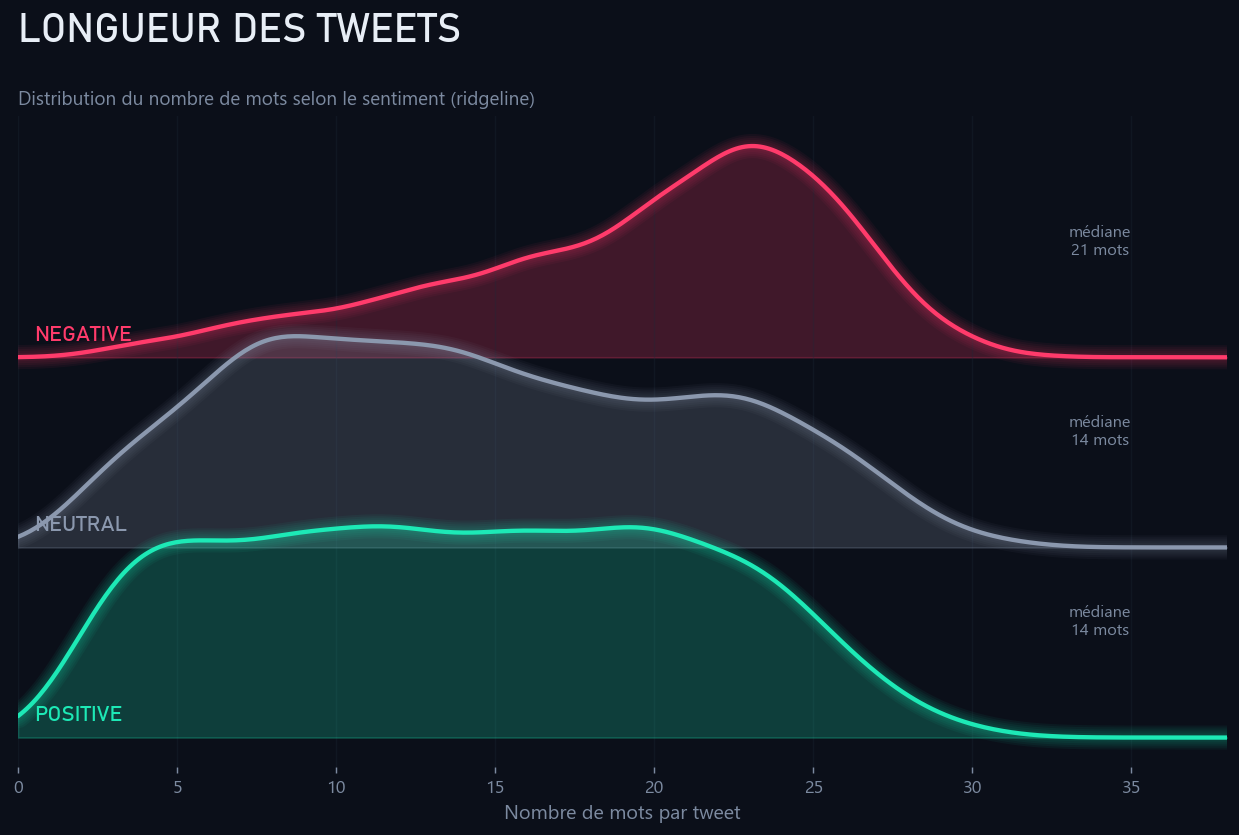

In [ ]:
fig = ef.fig_ridgeline(df, save=FIG/"longueur_ridgeline.png"); plt.show()

**Commentaire :** les tweets **négatifs sont plus longs** (médiane ~21 mots) — les gens
détaillent leurs griefs ; neutres/positifs plus courts (~14). La longueur guidera le **maxlen**
des modèles séquentiels (CNN/LSTM) du Lot 3.

### **2.4 Vocabulaire par sentiment (sur texte nettoyé)**

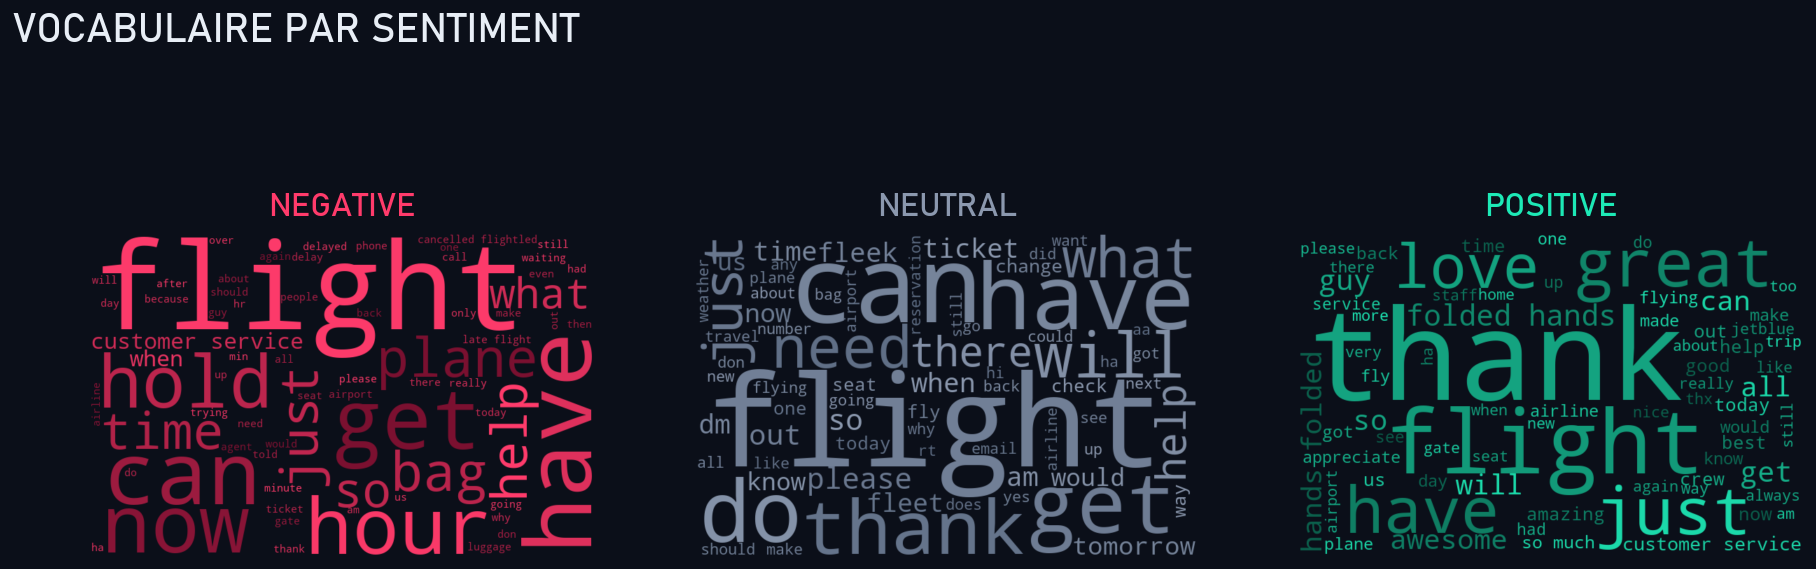

In [ ]:
fig = ef.fig_wordclouds(df, save=FIG/"nuages_mots_modern.png"); plt.show()

**Commentaire :** vocabulaire très discriminant — *delayed, cancelled, hours, hold, bag*
(négatif) vs *thanks, great, awesome, love* (positif). Le neutre est plus logistique/ambigu.
→ un fort signal lexical existe : la **baseline TF-IDF** devrait déjà bien performer.

### **2.5 Fiabilité des annotations**

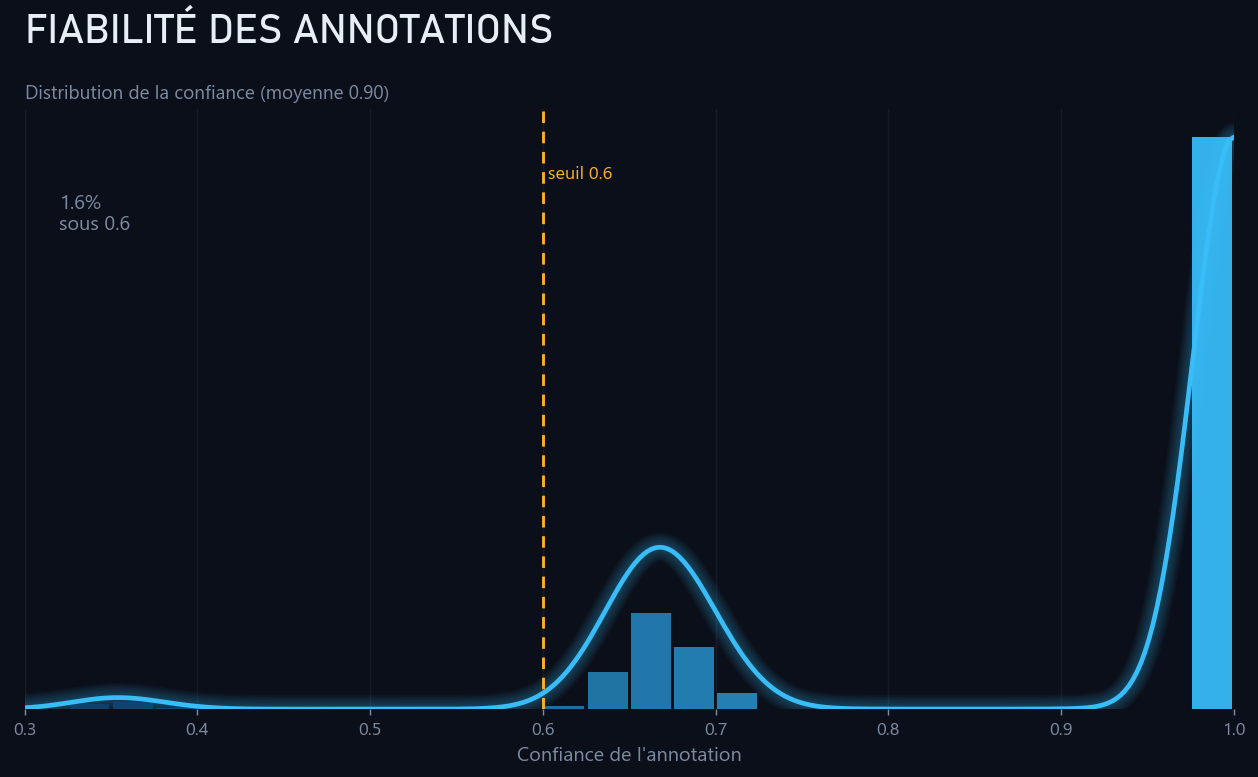

In [ ]:
fig = ef.fig_confiance(df, save=FIG/"confiance_modern.png"); plt.show()

**Commentaire :** confiance moyenne **0,90** ; une minorité < 0,6. **Décision :** on
**conserve tous les tweets** (filtrer réduirait surtout le neutre, déjà rare) et on garde la
colonne de confiance comme **pondération optionnelle** à tester au Lot 3. On ne filtre jamais le **test**.

## **3. Pipeline de nettoyage (reproductible)**

Centralisé dans **`src/text_cleaning.py`** → **identique** dans tous les lots. Choix justifiés :

| Étape | Choix | Pourquoi |
|-------|-------|----------|
| HTML unescape | `&amp;` → `&` | nettoyer les artefacts d'encodage |
| Emojis | 😡 → `enraged face` | **conserver** le signal de sentiment |
| Minuscules | oui | réduire la taille du vocabulaire |
| URLs | supprimées | bruit sans valeur sémantique |
| @mentions | supprimées | ce sont des **destinataires** (la compagnie), pas du sentiment |
| #hashtags | `#fail` → `fail` | le mot du hashtag est **informatif** |
| Chiffres isolés | supprimés | numéros de vol, peu utiles |
| Ponctuation | supprimée | simplifie la vectorisation |
| Stopwords | **conservés** | la **négation** ("not", "no") est cruciale → gérée au Lot 2 |


In [ ]:
for _, r in df[["text","text_clean"]].sample(5, random_state=1).iterrows():
    print("AVANT :", r["text"][:110])
    print("APRES :", r["text_clean"][:110]); print("-"*70)

vides = (df["text_clean"].str.strip()=="" ).sum()
print(f"\nTweets vides apres nettoyage : {vides} ({vides/len(df)*100:.2f}%)")

AVANT : @JetBlue I'll pass along the advice. You guys rock!!
APRES : i ll pass along the advice you guys rock
----------------------------------------------------------------------
AVANT : @united I sent you a dm with my file reference number.. I just want to know if someone has located my bag even
APRES : i sent you a dm with my file reference number i just want to know if someone has located my bag even if it s n
----------------------------------------------------------------------
AVANT : @SouthwestAir Black History Commercial is really sweet. Well done.
APRES : black history commercial is really sweet well done
----------------------------------------------------------------------
AVANT : @SouthwestAir why am I still in Baltimore?! @delta is doing laps around us and laughing about it. # ridiculous
APRES : why am i still in baltimore is doing laps around us and laughing about it ridiculous
----------------------------------------------------------------------
AVANT : @SouthwestAir 

In [ ]:
# On retire les rares tweets vides (uniquement mention/url) -> aucun signal textuel
avant = len(df)
df = df[df["text_clean"].str.strip()!=""].reset_index(drop=True)
print(f"Lignes conservees : {len(df)} (retirees : {avant-len(df)})")

Lignes conservees : 14640 (retirees : 0)


## **4. Stratégie face au déséquilibre des classes**

In [ ]:
ordre = ["negative", "neutral", "positive"]
classes = np.array(ordre)
weights = compute_class_weight("balanced", classes=classes, y=df["airline_sentiment"].values)
class_weight = {c: round(w, 3) for c, w in zip(classes, weights)}
print("Poids de classe 'balanced' :", class_weight)

Poids de classe 'balanced' : {np.str_('negative'): np.float64(0.532), np.str_('neutral'): np.float64(1.575), np.str_('positive'): np.float64(2.065)}


**Décision argumentée :**
- **Pas de ré-échantillonnage** au niveau des données (évite la fuite et la perte d'info).
- **Pondération des classes** appliquée à la *loss* (LogReg `class_weight='balanced'`, Keras `class_weight=`).
- **Métriques robustes** : F1 par classe + **F1-macro** + matrice de confusion (jamais l'accuracy seule).

## **5. Découpage train / validation / test (stratifié et figé)**

**70 / 15 / 15**, **stratifié** sur le sentiment, **`random_state=42`** → reproductible et
**identique pour tous les modèles**. Le **test** est mis de côté (évaluation finale uniquement).

In [ ]:
label2id = {"negative":0, "neutral":1, "positive":2}; id2label = {v:k for k,v in label2id.items()}
df["label"] = df["airline_sentiment"].map(label2id)
cols = ["tweet_id","text","text_clean","airline_sentiment","label",
        "airline","negativereason","airline_sentiment_confidence","retweet_count"]
data = df[cols].copy()

train_val, test = train_test_split(data, test_size=0.15, stratify=data["label"], random_state=42)
train, val = train_test_split(train_val, test_size=0.15/0.85, stratify=train_val["label"], random_state=42)
for name, d in [("train",train),("val",val),("test",test)]:
    print(f"{name:5}: {len(d):>6}  ({len(d)/len(data)*100:.1f}%)")

train:  10248  (70.0%)
val  :   2196  (15.0%)
test :   2196  (15.0%)


In [ ]:
# Verification : proportions de classes preservees
prop = pd.DataFrame({
    "global": data["airline_sentiment"].value_counts(normalize=True),
    "train":  train["airline_sentiment"].value_counts(normalize=True),
    "val":    val["airline_sentiment"].value_counts(normalize=True),
    "test":   test["airline_sentiment"].value_counts(normalize=True),
}).reindex(ordre).round(3)
print(prop)

                   global  train    val   test
airline_sentiment                             
negative            0.627  0.627  0.627  0.627
neutral             0.212  0.212  0.212  0.212
positive            0.161  0.161  0.161  0.161


In [ ]:
import json
train.to_csv(OUT/"train.csv", index=False, encoding="utf-8")
val.to_csv(OUT/"val.csv", index=False, encoding="utf-8")
test.to_csv(OUT/"test.csv", index=False, encoding="utf-8")
meta = {"label2id": label2id, "id2label": id2label, "class_weight": class_weight,
        "random_state": 42, "split": {"train": len(train), "val": len(val), "test": len(test)},
        "primary_metric": "f1_macro"}
(OUT/"meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print("Artefacts ecrits :", [f.name for f in sorted(OUT.glob('*'))])

Artefacts ecrits :

 ['meta.json', 'test.csv', 'train.csv', 'val.csv']


## **6. Synthèse du Lot 1**

✅ **EDA (dashboard)** — déséquilibre 63/21/16 ; US Airways/American/United les plus critiquées ;
motifs = service client, retards, annulations, bagages ; tweets négatifs plus longs ; vocabulaire
discriminant net ; confiance 0,90.

✅ **Nettoyage** — pipeline reproductible et justifié (`src/text_cleaning.py`), emojis convertis, négation préservée.

✅ **Déséquilibre** — pondération des classes + F1-macro, sans ré-échantillonnage.

✅ **Split figé** — `train/val/test` 70/15/15 stratifié (`random_state=42`), sauvegardé dans
`delivarables/data_processed/` avec `meta.json`.

➡️ **Prochaine étape : Lot 2 — représentations du texte (TF-IDF, Word2Vec, BERT opt.).**